In [1]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

# 1. 엑셀 파일 로드 및 전처리
df = pd.read_excel(
    './data/수면영향.xlsx', sheet_name='데이터', engine='openpyxl', header=[0, 1, 2]
)

# 2. 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df.iloc[:, 0] = df.iloc[:, 0].ffill()

# 3. '모름/무응답' 행 제거하기
col_name = df.columns[1]
df = df[df[col_name] != '모름/무응답']

# 4. 숫자 데이터 변환
for col in df.columns[2:]:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# 5. 5가지 카테고리 딕셔너리 생성
categories = {
    '성별': df[df.iloc[:, 0] == '성별'],
    '학력별(부)': df[df.iloc[:, 0] == '학력별(부)'],
    '학력별(모)': df[df.iloc[:, 0] == '학력별(모)'],
    '가구소득별': df[df.iloc[:, 0] == '가구소득별'],
    '시도별': df[df.iloc[:, 0] == '시도별'],
}

# 6. 순회하며 각각 출력
for name, sub_df in categories.items():
  print(f'[{name} 데이터]')

  styled_df = (
      sub_df.style.format(
          lambda x: f'{x:.1f}' if pd.notnull(x) else x,
          subset=sub_df.columns[3:],
      )
      .set_properties(**{'text-align': 'center'})
      .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
  )

  display(styled_df)
  print('\n' + '=' * 60 + '\n')

[성별 데이터]




[학력별(부) 데이터]




[학력별(모) 데이터]




[가구소득별 데이터]




[시도별 데이터]


[성별 데이터]


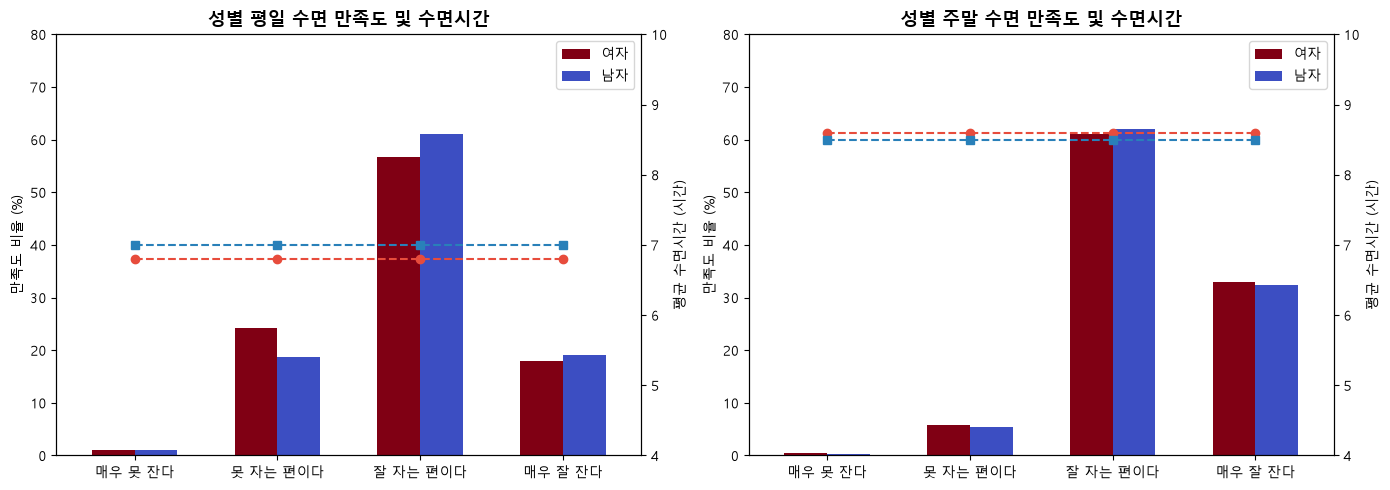

In [2]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt


# ====================================================
# 엑셀 데이터 로드 및 테이블 출력
# ====================================================
# 전처리
# (1) 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')

# (2) 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 1. 엑셀 파일 로드 
df = pd.read_excel(
    './data/수면영향.xlsx', sheet_name='데이터', engine='openpyxl', header=[0, 1, 2]
)

# 2. 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df.iloc[:, 0] = df.iloc[:, 0].ffill()

# 3. 숫자 데이터 변환
for col in df.columns[2:]:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# ----------------------------------------------------
# 성별 데이터 필터링 및 컬럼 정의
# ----------------------------------------------------
name = '성별'
sub_df = df[df.iloc[:, 0] == name].copy()

# 평일 만족도(컬럼 3~6) 및 주말 만족도(컬럼 9~12)
target_cols = list(df.columns[3:7]) + list(df.columns[9:13])

# 4. 데이터 표 출력
print(f'[{name} 데이터]')

styled_df = (
    sub_df.style.format(
        {
            sub_df.columns[2]: '{:.0f}',  # 사례수(소계) : 소수점 없이 정수로 표시
        },
        na_rep='',
    )
    .format(
        lambda x: f'{x:.1f}' if pd.notnull(x) else x,
        subset=sub_df.columns[3:],  # 비율 및 수면시간 : 소수점 첫째 자리까지 표시
    )
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

display(styled_df)
print('\n')


# ====================================================
# 그래프 그리기
# ====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------------------------------------
# [1] 평일: 수면 만족도 (막대) + 수면시간 (꺾은선)
# ----------------------------------------------------
# (1) 막대그래프 (왼쪽 Y축: 비율 %)
df_weekday = sub_df[target_cols[:4]].copy()
df_weekday.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekday.index = sub_df.iloc[:, 1]
df_weekday.index.name = None

df_weekday.T[['여자', '남자']].plot(
    kind='bar', ax=axes[0], color=['#800014', '#3C4EC2'], rot=0, width=0.6
)
axes[0].set_title('성별 평일 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[0].set_ylabel('만족도 비율 (%)')
axes[0].set_ylim(0, 80)

# (2) 꺾은선그래프 (오른쪽 Y축: 수면시간)
ax0_twin = axes[0].twinx()

# 표 기준 평일 수면시간(기상-취침 계산값 등)
female_sleep_wk = 6.8
male_sleep_wk = 7.0

# 막대 위치(x축 인덱스 0~3)에 맞춰 꺾은선 배치
ax0_twin.plot([0, 1, 2, 3], [female_sleep_wk]*4, color='#e74c3c', marker='o', linestyle='--', label='여자 수면시간')
ax0_twin.plot([0, 1, 2, 3], [male_sleep_wk]*4, color='#2980b9', marker='s', linestyle='--', label='남자 수면시간')

ax0_twin.set_ylabel('평균 수면시간 (시간)')
ax0_twin.set_ylim(4, 10) # 수면시간 범위에 맞춰 조정

# ----------------------------------------------------
# [2] 주말: 수면 만족도 (막대) + 수면시간 (꺾은선)
# ----------------------------------------------------
# (1) 막대그래프 (왼쪽 Y축: 비율 %)
df_weekend = sub_df[target_cols[4:]].copy()
df_weekend.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekend.index = sub_df.iloc[:, 1]
df_weekend.index.name = None

df_weekend.T[['여자', '남자']].plot(
    kind='bar', ax=axes[1], color=['#800014', '#3C4EC2'], rot=0, width=0.6
)
axes[1].set_title('성별 주말 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[1].set_ylabel('만족도 비율 (%)')
axes[1].set_ylim(0, 80)

# (2) 꺾은선그래프 (오른쪽 Y축: 수면시간)
ax1_twin = axes[1].twinx()

female_sleep_we = 8.6
male_sleep_we = 8.5

ax1_twin.plot([0, 1, 2, 3], [female_sleep_we]*4, color='#e74c3c', marker='o', linestyle='--', label='여자 수면시간')
ax1_twin.plot([0, 1, 2, 3], [male_sleep_we]*4, color='#2980b9', marker='s', linestyle='--', label='남자 수면시간')

ax1_twin.set_ylabel('평균 수면시간 (시간)')
ax1_twin.set_ylim(4, 10)

plt.tight_layout()
plt.show()

학력별(부/모)데이터


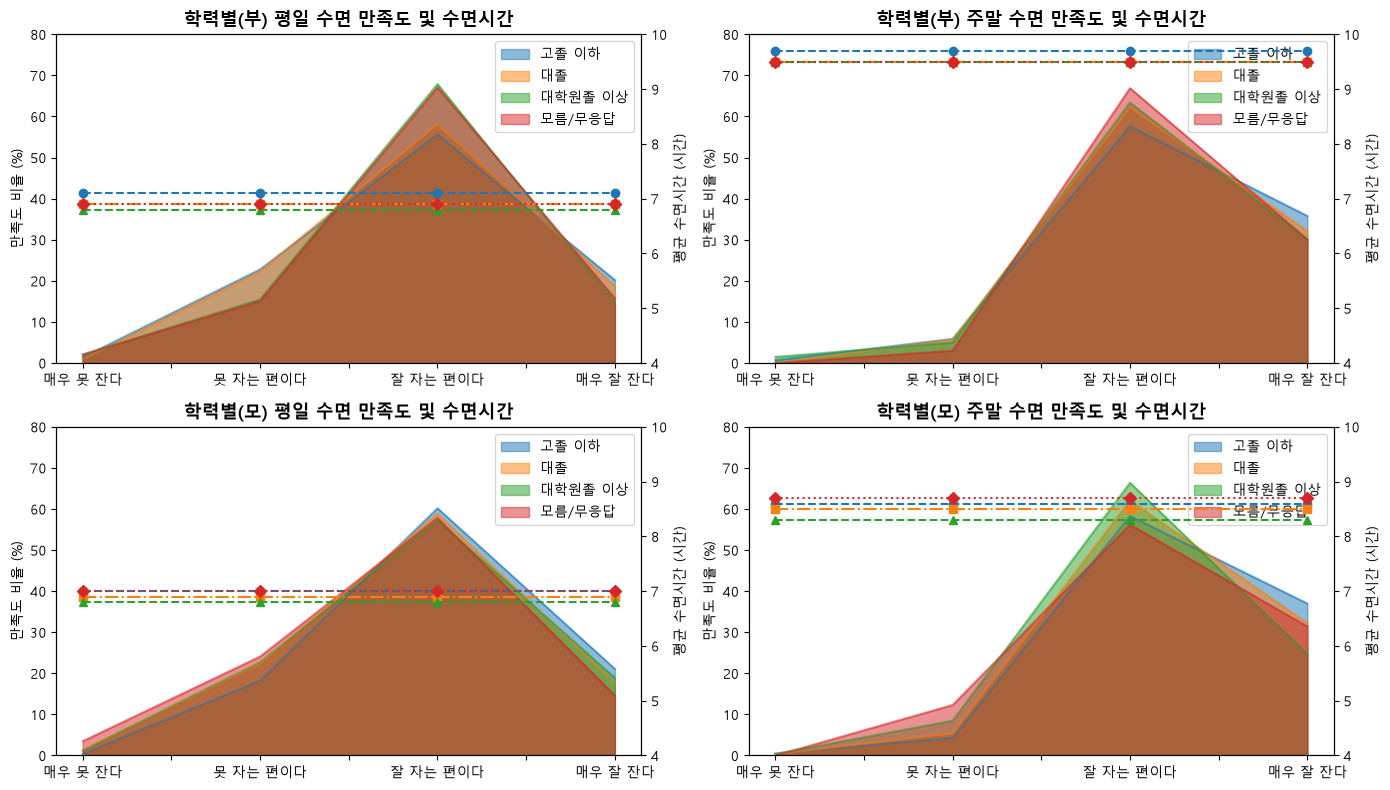

In [3]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt


# ====================================================
# 엑셀 데이터 로드 및 테이블 출력
# ====================================================
# 전처리
# (1) 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')

# (2) 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

# 1. 엑셀 파일 로드 
df = pd.read_excel(
    './data/수면영향.xlsx', sheet_name='데이터', engine='openpyxl', header=[0, 1, 2]
)

# 2. 누락값(NaN)을 앞 데이터로 채움(엑셀 양식 병합 부분)
df.iloc[:, 0] = df.iloc[:, 0].ffill()

# 3. 숫자 데이터 변환
for col in df.columns[2:]:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# ----------------------------------------------------
# 학력별(부) 데이터 필터링 및 컬럼 정의
# ----------------------------------------------------
sub_df_dad = df[df.iloc[:, 0] == '학력별(부)'].copy()
sub_df_mom = df[df.iloc[:, 0] == '학력별(모)'].copy()
sub_df = pd.concat([sub_df_dad, sub_df_mom], ignore_index=True)

# 평일 만족도(컬럼 3~6) 및 주말 만족도(컬럼 9~12)
target_cols = list(df.columns[3:7]) + list(df.columns[9:13])

# 4. 데이터 표 출력
print('학력별(부/모)데이터')

styled_df = (
    sub_df.style.format(
        {
            sub_df.columns[2]: '{:.0f}',  # 사례수(소계) : 소수점 없이 정수로 표시
        },
        na_rep='',
    )
    .format(
        lambda x: f'{x:.1f}' if pd.notnull(x) else x,
        subset=sub_df.columns[3:],  # 비율 및 수면시간 : 소수점 첫째 자리까지 표시
    )
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])
)

display(styled_df)
print('\n')

# ====================================================
# 그래프 그리기
# ====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ----------------------------------------------------
# [1] 평일: 수면 만족도 (면적) + 수면시간 (꺾은선)
# ----------------------------------------------------
# (1) 면적그래프 (왼쪽 Y축: 비율 %)
df_weekday_dad = sub_df_dad[target_cols[:4]].copy()
df_weekday_dad.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekday_dad.index = sub_df_dad.iloc[:, 1]
df_weekday_dad.index.name = None

df_weekday_dad.T[['고졸 이하', '대졸', '대학원졸 이상', '모름/무응답']].plot(
    kind='area', ax=axes[0][0], stacked=False
)
axes[0][0].set_title('학력별(부) 평일 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[0][0].set_ylabel('만족도 비율 (%)')
axes[0][0].set_ylim(0, 80)

df_weekday_mom = sub_df_mom[target_cols[:4]].copy()
df_weekday_mom.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekday_mom.index = sub_df_mom.iloc[:, 1]
df_weekday_mom.index.name = None

df_weekday_mom.T[['고졸 이하', '대졸', '대학원졸 이상', '모름/무응답']].plot(
    kind='area', ax=axes[1][0], stacked=False
)
axes[1][0].set_title('학력별(모) 평일 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[1][0].set_ylabel('만족도 비율 (%)')
axes[1][0].set_ylim(0, 80)

# (2) 꺾은선그래프 (오른쪽 Y축: 수면시간)
ax0_twin_dad = axes[0][0].twinx()
ax0_twin_mom = axes[1][0].twinx()


# 표 기준 평일 수면시간(기상-취침 계산값 등)
high_sleep_wk_dad = 7.1
univ_sleep_wk_dad = 6.9
grad_sleep_wk_dad = 6.8
none_sleepl_wk_dad = 6.9

high_sleep_wk_mom = 7.0
univ_sleep_wk_mom = 6.9
grad_sleep_wk_mom = 6.8
none_sleepl_wk_mom = 7.0

# 면적위치(x축 인덱스 0~3)에 맞춰 꺾은선 배치
ax0_twin_dad.plot([0, 1, 2, 3], [high_sleep_wk_dad]*4, marker='o', linestyle='--', label='고졸 이하 수면시간')
ax0_twin_dad.plot([0, 1, 2, 3], [univ_sleep_wk_dad]*4, marker='s', linestyle='-.', label='대졸 수면시간')
ax0_twin_dad.plot([0, 1, 2, 3], [grad_sleep_wk_dad]*4, marker='^', linestyle='--', label='대학원졸 수면시간')
ax0_twin_dad.plot([0, 1, 2, 3], [none_sleepl_wk_dad]*4, marker='D', linestyle=':', label='모름/무응답 수면시간')

ax0_twin_dad.set_ylabel('평균 수면시간 (시간)')
ax0_twin_dad.set_ylim(4, 10) # 수면시간 범위에 맞춰 조정

ax0_twin_mom.plot([0, 1, 2, 3], [high_sleep_wk_mom]*4, marker='o', linestyle='--', label='고졸 이하 수면시간')
ax0_twin_mom.plot([0, 1, 2, 3], [univ_sleep_wk_mom]*4, marker='s', linestyle='-.', label='대졸 수면시간')
ax0_twin_mom.plot([0, 1, 2, 3], [grad_sleep_wk_mom]*4, marker='^', linestyle='--', label='대학원졸 수면시간')
ax0_twin_mom.plot([0, 1, 2, 3], [none_sleepl_wk_mom]*4, marker='D', linestyle=':', label='모름/무응답 수면시간')

ax0_twin_mom.set_ylabel('평균 수면시간 (시간)')
ax0_twin_mom.set_ylim(4, 10)

# ----------------------------------------------------
# [2] 주말: 수면 만족도 (면적) + 수면시간 (꺾은선)
# ----------------------------------------------------
# (1) 면적그래프 (왼쪽 Y축: 비율 %)
df_weekend_dad = sub_df_dad[target_cols[4:]].copy()
df_weekend_dad.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekend_dad.index = sub_df_dad.iloc[:, 1]
df_weekend_dad.index.name = None

df_weekend_dad.T[['고졸 이하', '대졸', '대학원졸 이상', '모름/무응답']].plot(
    kind='area', ax=axes[0][1], stacked=False
)
axes[0][1].set_title('학력별(부) 주말 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[0][1].set_ylabel('만족도 비율 (%)')
axes[0][1].set_ylim(0, 80)

df_weekend_mom = sub_df_mom[target_cols[4:]].copy()
df_weekend_mom.columns = ['매우 못 잔다', '못 자는 편이다', '잘 자는 편이다', '매우 잘 잔다']
df_weekend_mom.index = sub_df_mom.iloc[:, 1]
df_weekend_mom.index.name = None

df_weekend_mom.T[['고졸 이하', '대졸', '대학원졸 이상', '모름/무응답']].plot(
    kind='area', ax=axes[1][1], stacked=False
)
axes[1][1].set_title('학력별(모) 주말 수면 만족도 및 수면시간', fontsize=13, fontweight='bold')
axes[1][1].set_ylabel('만족도 비율 (%)')
axes[1][1].set_ylim(0, 80)

# (2) 꺾은선그래프 (오른쪽 Y축: 수면시간)
ax1_twin_dad = axes[0][1].twinx()
ax1_twin_mom = axes[1][1].twinx()

high_sleep_we_dad = 9.7
univ_sleep_we_dad = 9.5
grad_sleep_we_dad = 9.5
none_sleepl_we_dad = 9.5

high_sleep_we_mom = 8.6
univ_sleep_we_mom = 8.5
grad_sleep_we_mom = 8.3
none_sleepl_we_mom = 8.7

ax1_twin_dad.plot([0, 1, 2, 3], [high_sleep_we_dad]*4, marker='o', linestyle='--', label='고졸 이하 수면시간')
ax1_twin_dad.plot([0, 1, 2, 3], [univ_sleep_we_dad]*4, marker='s', linestyle='-.', label='대졸 수면시간')
ax1_twin_dad.plot([0, 1, 2, 3], [grad_sleep_we_dad]*4, marker='^', linestyle='--', label='대학원졸 수면시간')
ax1_twin_dad.plot([0, 1, 2, 3], [none_sleepl_we_dad]*4, marker='D', linestyle=':', label='모름/무응답 수면시간')

ax1_twin_dad.set_ylabel('평균 수면시간 (시간)')
ax1_twin_dad.set_ylim(4, 10)

ax1_twin_mom.plot([0, 1, 2, 3], [high_sleep_we_mom]*4, marker='o', linestyle='--', label='고졸 이하 수면시간')
ax1_twin_mom.plot([0, 1, 2, 3], [univ_sleep_we_mom]*4, marker='s', linestyle='-.', label='대졸 수면시간')
ax1_twin_mom.plot([0, 1, 2, 3], [grad_sleep_we_mom]*4, marker='^', linestyle='--', label='대학원졸 수면시간')
ax1_twin_mom.plot([0, 1, 2, 3], [none_sleepl_we_mom]*4, marker='D', linestyle=':', label='모름/무응답 수면시간')

ax1_twin_mom.set_ylabel('평균 수면시간 (시간)')
ax1_twin_mom.set_ylim(4, 10)

plt.tight_layout()
plt.show()